In [53]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
import os

In [54]:
load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: Union[str, ForwardRef('os.PathLike[str]'), NoneType] = None, stream: Optional[IO[str]] = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: Optional[str] = 'utf-8') -> bool>

In [55]:
# Defining State
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixs: int

    sr: float
    boundry_percent: float
    bpb: float
    summary: str

In [56]:
def calculate_sr(state: BatsmanState):
    runs = state['runs']
    balls = state['balls']

    sr = (runs/balls)*100
    # state['sr'] = sr
    # return state

    return {'sr': sr}

In [57]:
def calculate_boundary_percent(state: BatsmanState):
    boundry_percent = (((state['fours']*4) + (state['sixs']*6))/state['runs'])*100


    # state['boundry_percent']=boundry_percent
    # return state['boundry_percent']

    return {'boundry_percent': boundry_percent}


In [58]:
def calculate_bpb(state: BatsmanState):
    bpb = state['balls'] / (state['fours'] + state['sixs'])

    # state['bpb'] = bpb
    # return state['bpb']

    return {'bpb': bpb}

In [59]:
def summary(state: BatsmanState):
    summary = f"""
Boundry percent - {state['boundry_percent']} \n
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']}"""

    # state['summary'] = summary
    # return state['summary']

    return {'summary': summary}

In [60]:
# creating graph
graph = StateGraph(BatsmanState)

# adding nodes to the graph
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('summary', summary)

# adding edges to the graph
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_boundary_percent')
graph.add_edge(START, 'calculate_bpb')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')
graph.add_edge('calculate_bpb', 'summary')

graph.add_edge('summary', END)


# compiling the graph

workflow = graph.compile()



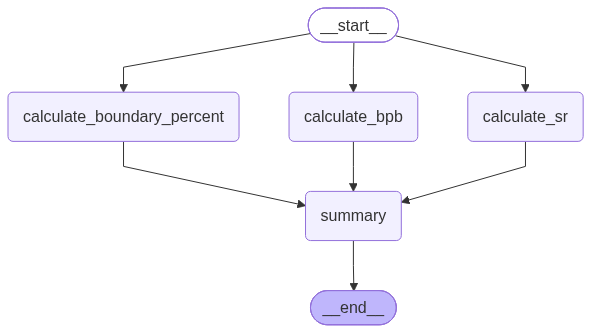

In [45]:
workflow

In [50]:
#executing the graph/workflow

initial_state = {'runs':100, 'balls':40, 'fours':4, 'sixs':6 }
final_state = workflow.invoke(initial_state)
print(final_state)

{'runs': 100, 'balls': 40, 'fours': 4, 'sixs': 6, 'sr': 250.0, 'boundry_percent': 52.0, 'bpb': 4.0, 'summary': '\nBoundry percent - 52.0 \n\nStrike Rate - 250.0 \n\nBalls per boundary - 4.0'}
